## Continuous PINN: Learning Ecosystem Dynamics

We train a neural network to approximate the full solution trajectory
of an NPZ (nutrient-phytoplankton-zooplankton) system:

$$\mathbf{x}(t) = f_\theta(t)$$

The network takes time as input and outputs the state (N, P, Z).
A physics loss constrains the network to satisfy the NPZ equations
everywhere, not just at observation times.


### Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

tf.random.set_seed(42)
np.random.seed(42)

def mse(y_true, y_pred):
    return np.mean((y_true - y_pred)**2)
    

### Load & Inspect

In [2]:
# --- Load data ---
df = pd.read_csv("../../data/npz_narragansett/data_npz_narragansett.csv")
df.columns = ["time", "NO3", "P", "Z"]

print(df.head())
print(f"\nShape: {df.shape}")
print(f"Time range: {df.time.min():.0f} – {df.time.max():.0f} days")


   time     NO3       P       Z
0   1.0  0.2880  0.0379  0.0100
1   8.0  0.3596  0.0644  0.0006
2  15.0  0.3569  0.0501  0.0073
3  22.0  0.4147  0.0343  0.0328
4  29.0  0.5691  0.0558  0.0016

Shape: (337, 4)
Time range: 1 – 2983 days


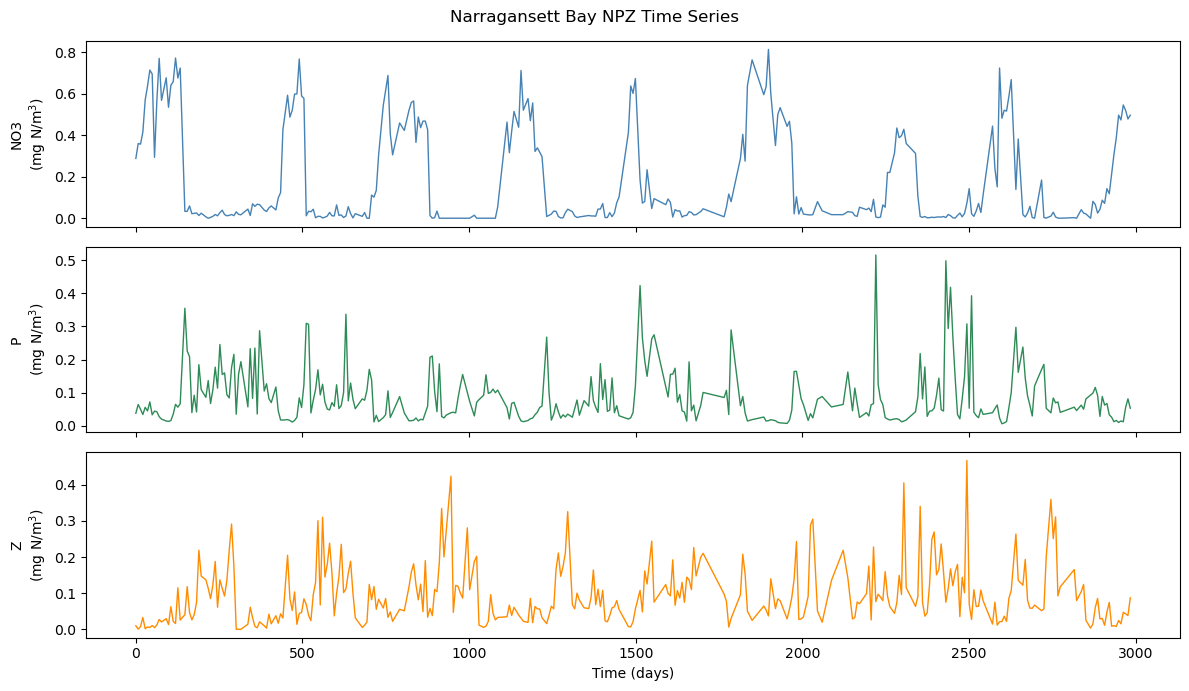

In [3]:
fig_ts, axes_ts = plt.subplots(3, 1, figsize=(12, 7), sharex=True)

for ax, col, color in zip(axes_ts, 
                           ["NO3", "P", "Z"], 
                           ["steelblue", "seagreen", "darkorange"]):
    ax.plot(df.time, df[col], color=color, lw=1)
    ax.set_ylabel(f"{col}\n" + r"(mg N/m$^3$)")

axes_ts[-1].set_xlabel("Time (days)")
plt.suptitle("Narragansett Bay NPZ Time Series")
plt.tight_layout()
plt.show()


### Normalize

In [4]:
# Divide all concentrations by maximum total nitrogen so values fall in [0,1]
# Physical ranges for residual normalization (before scaling)
N_range = float(df['NO3'].max() - df['NO3'].min())
P_range = float(df['P'].max()   - df['P'].min())
Z_range = float(df['Z'].max()   - df['Z'].min())

# Divide all concentrations by maximum total nitrogen so values fall in [0,1]
scale = (df['NO3'] + df['P'] + df['Z']).max()
df[['NO3', 'P', 'Z']] = df[['NO3', 'P', 'Z']] / scale
print(f"Normalization scale: {scale:.4f} mg N/m³")

# Normalize time to [0, 1]
t_min = df.time.min()
t_max = df.time.max()
df['t_norm'] = (df.time - t_min) / (t_max - t_min)


Normalization scale: 0.8952 mg N/m³


### Train/test split (random 80/20)

In [5]:
# Random split is appropriate here because the network takes time as
# input and learns a continuous trajectory -- it can interpolate between
# any observations regardless of position in the record.
np.random.seed(42)
idx = np.random.permutation(len(df))
n_train = int(0.8 * len(df))
df_train = df.iloc[np.sort(idx[:n_train])].reset_index(drop=True)
df_test  = df.iloc[np.sort(idx[n_train:])].reset_index(drop=True)


In [6]:
# ── Prepare TensorFlow tensors ───────────────────────────────────────
t_train = tf.constant(df_train['t_norm'].values.reshape(-1, 1), dtype=tf.float32)
y_train = tf.constant(df_train[['NO3', 'P', 'Z']].values, dtype=tf.float32)

t_test = tf.constant(df_test['t_norm'].values.reshape(-1, 1), dtype=tf.float32)
y_test = tf.constant(df_test[['NO3', 'P', 'Z']].values, dtype=tf.float32)

# Dense time grid for plotting
t_dense = tf.constant(np.linspace(0, 1, 1000).reshape(-1, 1), dtype=tf.float32)
t_dense_days = np.linspace(t_min, t_max, 1000)


In [7]:
# ── NPZ parameters (Franks 1986) ─────────────────────────────────────
Vm    = 2.0    # max phytoplankton growth rate (day-1)
ks    = 1.0    # half-saturation constant (mg N/m3)
m     = 0.1    # phytoplankton mortality rate (day-1)
Rm    = 1.5    # max zooplankton grazing rate (day-1)
ivlev = 1.0    # Ivlev constant (m3/mg N)
gamma = 0.3    # zooplankton assimilation efficiency
q     = 0.1    # zooplankton mortality rate (day-1)

dt_scale = t_max - t_min  # days spanned by the record

# ── Collocation points for physics loss ──────────────────────────────
t_phys = tf.constant(np.linspace(0, 1, 500).reshape(-1, 1), dtype=tf.float32)

# ── Physics loss function ────────────────────────────────────────────
# The network outputs scaled variables y in [0,1].
# The ODE is evaluated in physical units (mg N/m3, days).
# Each residual is divided by the physical range of that variable
# to make the physics loss dimensionless and O(1).

def pinn_loss(model, t_obs, y_obs, t_phys, lam=1.0):
    # Data loss (scaled space)
    y_pred = model(t_obs)
    loss_data = tf.reduce_mean((y_pred - y_obs)**2)

    # Physics loss (physical units, residuals normalized by range)
    with tf.GradientTape(persistent=True) as tape:
        tape.watch(t_phys)
        y = model(t_phys)
        N = y[:, 0:1] * scale
        P = y[:, 1:2] * scale
        Z = y[:, 2:3] * scale
    dNdt = tape.gradient(N, t_phys) / dt_scale
    dPdt = tape.gradient(P, t_phys) / dt_scale
    dZdt = tape.gradient(Z, t_phys) / dt_scale
    del tape

    uptake  = (Vm * N / (ks + N)) * P
    grazing = Rm * (1 - tf.exp(-ivlev * P)) * Z

    f_N = (dNdt - (-uptake + m * P + q * Z + gamma * grazing)) / N_range
    f_P = (dPdt - (uptake  - m * P - grazing)) / P_range
    f_Z = (dZdt - ((1 - gamma) * grazing - q * Z)) / Z_range

    loss_phys = tf.reduce_mean(f_N**2 + f_P**2 + f_Z**2)
    return loss_data + lam * loss_phys, loss_data, loss_phys
    

In [8]:
# # ── Grid search ──────────────────────────────────────────────────────
# from itertools import product

# param_grid = {
#     'hidden':     [[32, 32], [64, 64], [128, 128], [64, 64, 64]],
#     'lr':         [1e-3, 5e-4],
#     'activation': ['gelu', 'tanh'],
#     'lam':        [0.01, 0.1, 1.0, 10.0],
# }

# num_epochs = 5000
# patience = 100

# configs = list(product(
#     param_grid['hidden'], param_grid['lr'],
#     param_grid['activation'], param_grid['lam']))
# print(f"Testing {len(configs)} configurations...")

# results = []
# for i, (hidden, lr, act, lam) in enumerate(configs):
#     tf.random.set_seed(42)
    
#     model = tf.keras.Sequential()
#     model.add(tf.keras.layers.Input(shape=(1,)))
#     for units in hidden:
#         model.add(tf.keras.layers.Dense(units, activation=act))
#     model.add(tf.keras.layers.Dense(3))
    
#     optimizer = tf.keras.optimizers.Adam(lr)
    
#     best_val = np.inf
#     best_wts = None
#     wait = 0
    
#     for epoch in range(num_epochs):
#         with tf.GradientTape() as tape:
#             loss, l_data, l_phys = pinn_loss(model, t_train, y_train, t_phys, lam=lam)
#         grads = tape.gradient(loss, model.trainable_variables)
#         optimizer.apply_gradients(zip(grads, model.trainable_variables))
        
#         val_pred = model(t_test)
#         val_loss = tf.reduce_mean((val_pred - y_test)**2).numpy()
        
#         if (epoch + 1) % 500 == 0:
#             print(f"    config {i+1} epoch {epoch+1}: total={loss.numpy():.6f} data={l_data.numpy():.6f} phys={l_phys.numpy():.6f} val={val_loss:.6f}")
        
#         if val_loss < best_val:
#             best_val = val_loss
#             best_wts = [w.numpy().copy() for w in model.trainable_variables]
#             wait = 0
#         else:
#             wait += 1
#         if wait >= patience:
#             break
    
#     results.append({
#         'hidden': hidden, 'lr': lr, 'activation': act, 'lam': lam,
#         'val_loss': best_val, 'epochs': epoch + 1
#     })
#     print(f"[{i+1}/{len(configs)}] hidden={str(hidden):16s} lr={lr:.0e} act={act:8s} "
#           f"lam={lam:5.2f}  val={best_val:.6f}  epochs={epoch+1}")

# results_df = pd.DataFrame(results).sort_values('val_loss')
# print(f"\nTop 5:")
# print(results_df.head().to_string(index=False))


In [9]:
# ── Train PINN ───────────────────────────────────────────────────────
tf.random.set_seed(42)
model = tf.keras.Sequential()
model.add(tf.keras.layers.Input(shape=(1,)))
model.add(tf.keras.layers.Dense(64, activation='tanh'))
model.add(tf.keras.layers.Dense(64, activation='tanh'))
model.add(tf.keras.layers.Dense(3))
optimizer = tf.keras.optimizers.Adam(1e-3)
lam = 1.0
num_epochs = 30000
patience = 1000
best_loss = np.inf
best_wts = None
wait = 0

for epoch in range(num_epochs):
    with tf.GradientTape() as tape:
        loss, l_data, l_phys = pinn_loss(model, t_train, y_train, t_phys, lam=lam)
    grads = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))

    if (epoch + 1) % 1000 == 0:
        val_pred = model(t_test)
        val_loss = tf.reduce_mean((val_pred - y_test)**2).numpy()
        print(f"Epoch {epoch+1}  total: {loss.numpy():.6f}  data: {l_data.numpy():.6f}  phys: {l_phys.numpy():.6f}  val: {val_loss:.6f}")

    if loss.numpy() < best_loss:
        best_loss = loss.numpy()
        best_wts = [w.numpy().copy() for w in model.trainable_variables]
        wait = 0
    else:
        wait += 1

    if wait >= patience:
        print(f"Early stopping at epoch {epoch+1}, best loss: {best_loss:.6f}")
        break

for w, wb in zip(model.trainable_variables, best_wts):
    w.assign(wb)
    

Epoch 1000  total: 0.028335  data: 0.028164  phys: 0.000171  val: 0.022403
Epoch 2000  total: 0.027524  data: 0.027384  phys: 0.000139  val: 0.022332
Epoch 3000  total: 0.026002  data: 0.025901  phys: 0.000101  val: 0.021798
Epoch 4000  total: 0.024348  data: 0.024203  phys: 0.000146  val: 0.020983
Epoch 5000  total: 0.023677  data: 0.023528  phys: 0.000149  val: 0.020865
Epoch 6000  total: 0.023516  data: 0.023362  phys: 0.000154  val: 0.020858
Epoch 7000  total: 0.023432  data: 0.023290  phys: 0.000142  val: 0.020808
Epoch 8000  total: 0.023394  data: 0.023245  phys: 0.000149  val: 0.020734
Epoch 9000  total: 0.023342  data: 0.023184  phys: 0.000158  val: 0.020590
Epoch 10000  total: 0.023268  data: 0.023092  phys: 0.000175  val: 0.020279
Epoch 11000  total: 0.023189  data: 0.023004  phys: 0.000185  val: 0.019749
Epoch 12000  total: 0.023115  data: 0.022938  phys: 0.000178  val: 0.019305
Epoch 13000  total: 0.023067  data: 0.022898  phys: 0.000169  val: 0.019042
Epoch 14000  total: 0

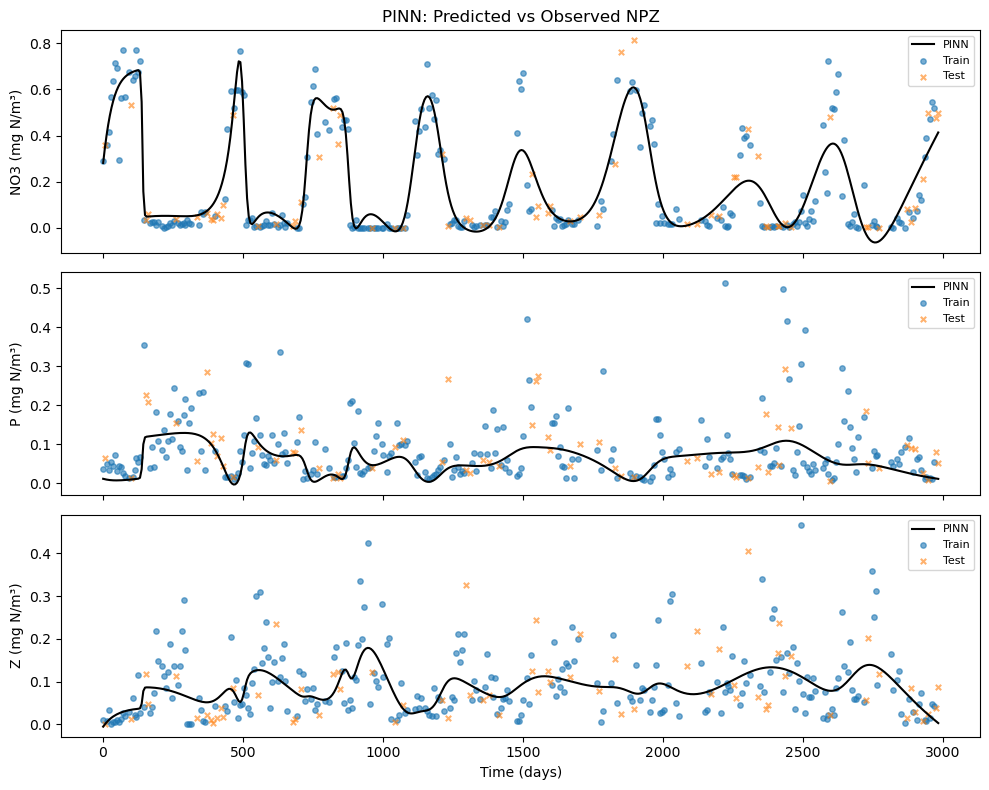

In [10]:
# ── Predicted vs observed ────────────────────────────────────────────
t_dense = tf.constant(np.linspace(0, 1, 500).reshape(-1, 1), dtype=tf.float32)
y_dense = model(t_dense).numpy() * scale
t_dense_days = t_dense.numpy().flatten() * dt_scale + t_min

labels = ['NO3', 'P', 'Z']
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
for j, ax in enumerate(axes):
    ax.plot(t_dense_days, y_dense[:, j], 'k-', lw=1.5, label='PINN')
    ax.scatter(t_train.numpy().flatten() * dt_scale + t_min,
               y_train.numpy()[:, j] * scale, s=15, alpha=0.6, label='Train')
    ax.scatter(t_test.numpy().flatten() * dt_scale + t_min,
               y_test.numpy()[:, j] * scale, s=15, alpha=0.6, marker='x', label='Test')
    ax.set_ylabel(f'{labels[j]} (mg N/m³)')
    ax.legend(loc='upper right', fontsize=8)
axes[-1].set_xlabel('Time (days)')
axes[0].set_title('PINN: Predicted vs Observed NPZ')
plt.tight_layout()
plt.show()
